In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## 导入库

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models.quantization as qmodels
import torch.ao.quantization as quant
import matplotlib.pyplot as plt
import time
import os

## 手动编写量化linear_quantize和反量化核心函数linear_dequantize

In [2]:
def linear_quantize(x, num_bits=8):
    q_min, q_max = 0, (1 << num_bits) - 1
    x_min, x_max = x.min().item(), x.max().item()
    if x_min == x_max:
        return torch.zeros_like(x, dtype=torch.uint8), 1.0, 0
    scale = (x_max - x_min) / (q_max - q_min)
    zero_point = round(q_min - (x_min / scale))
    zero_point = max(q_min, min(q_max, zero_point))
    q_x = torch.clamp(torch.round(x / scale) + zero_point, q_min, q_max)
    return q_x.to(torch.uint8), scale, zero_point

In [3]:
def linear_dequantize(q, scale, zero_point):
    return (q.float() - zero_point) * scale

## 构建支持量化的 ModifiedResNet18
这里沿用了作业2中设计的ResNet网络结构

In [6]:
class QuantizableModifiedResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        # 实例化量化版 resnet18
        self.resnet = qmodels.resnet18(weights=None, quantize=False)

        # 保持与作业2一致的头部修改
        self.resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 10)

    def forward(self, x):
        return self.resnet(x)

    def fuse_model(self):
        # 融合算子
        self.resnet.fuse_model(is_qat=False)

## 辅助测试函数
用于计算模型的推理准确率和推理速度

In [7]:
def evaluate_model(model, dataloader, device="cpu"):
    model.eval()
    correct, total = 0, 0
    start_time = time.perf_counter()
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)
    latency = (time.perf_counter() - start_time) / total * 1000
    return 100 * correct / total, latency

## 主函数

## 加载数据集
从 SVHN 训练集抽取⽆标注样本作为校准集，使⽤校准集进⾏模型校准。

In [9]:
# 限制单线程以测出最真实的 CPU 推理加速比
torch.set_num_threads(1)
BATCH_SIZE = 64

# --- 数据加载 ---
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.4377, 0.4438, 0.4728), (0.1980, 0.2010, 0.1970))])
train_dataset = torchvision.datasets.SVHN(root='./data', split='train', download=False, transform=transform)
test_dataset = torchvision.datasets.SVHN(root='./data', split='test', download=False, transform=transform)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

calib_indices = torch.randperm(len(train_dataset))[:500]
calib_sampler = torch.utils.data.SubsetRandomSampler(calib_indices)
calib_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=calib_sampler)

## 加载作业2保存的 ResNet 权重

In [10]:
model_fp32 = QuantizableModifiedResNet18()

# 因为我们在外面套了一层 class QuantizableModifiedResNet18，
# 里面的网络叫 self.resnet，所以加载权重时字典的 key 需要对齐
model_path = "svhn_model.pth"
if os.path.exists(model_path):
    print(f"找到权重 {model_path}，正在加载...")
    state_dict = torch.load(model_path, map_location="cpu")

    # 将原权重的 key 改名适配新模型 (如果原权重有 resnet. 前缀则不需要)
    new_state_dict = {}
    for k, v in state_dict.items():
        if not k.startswith('resnet.'):
            new_state_dict[f'resnet.{k}'] = v
        else:
            new_state_dict[k] = v

    model_fp32.load_state_dict(new_state_dict, strict=False)
    print("ResNet18 权重加载成功！")
else:
    print("未找到 svhn_model.pth，使用随机权重进行演示。")

找到权重 svhn_model.pth，正在加载...
ResNet18 权重加载成功！


## 使用自定义函数计算各层误差

In [11]:
model_fp32.eval()
fp32_acc, fp32_latency = evaluate_model(model_fp32, test_loader)
torch.save(model_fp32.state_dict(), "fp32_model.pth")
fp32_size = os.path.getsize("fp32_model.pth") / (1024 * 1024)

# 使用自定义函数计算各层误差
print("\n--- 计算各层输出量化 MSE 误差 ---")
sample_imgs, _ = next(iter(calib_loader))

with torch.no_grad():
    # 提取 ResNet 第一层 Conv1 输出
    out_conv1_fp32 = model_fp32.resnet.conv1(sample_imgs)
    q_out, scale, zp = linear_quantize(out_conv1_fp32)
    dq_out_conv1 = linear_dequantize(q_out, scale, zp)
    mse_conv1 = F.mse_loss(out_conv1_fp32, dq_out_conv1).item()

    # 提取 ResNet 最后一层 FC 之前的特征图
    x = model_fp32.resnet.maxpool(model_fp32.resnet.relu(model_fp32.resnet.bn1(out_conv1_fp32)))
    x = model_fp32.resnet.layer1(x)
    x = model_fp32.resnet.layer2(x)
    x = model_fp32.resnet.layer3(x)
    x = model_fp32.resnet.layer4(x)
    x = model_fp32.resnet.avgpool(x)
    flattened = torch.flatten(x, 1)

    out_fc_fp32 = model_fp32.resnet.fc(flattened)
    q_out_fc, scale_fc, zp_fc = linear_quantize(out_fc_fp32)
    dq_out_fc = linear_dequantize(q_out_fc, scale_fc, zp_fc)
    mse_fc = F.mse_loss(out_fc_fp32, dq_out_fc).item()

print(f"ResNet Conv1 层输出 MSE 误差: {mse_conv1:.6f}")
print(f"ResNet FC 层输出 MSE 误差: {mse_fc:.6f}")


--- 计算各层输出量化 MSE 误差 ---
ResNet Conv1 层输出 MSE 误差: 0.000072
ResNet FC 层输出 MSE 误差: 0.000779


## PyTorch 静态量化流程 (PTQ)
算子融合、⾮对称线性量化

In [12]:
print("\n--- 开始执行 INT8 静态模型转换 ---")
model_int8 = QuantizableModifiedResNet18()
model_int8.load_state_dict(model_fp32.state_dict())
model_int8.eval()

# 算子融合
model_int8.fuse_model()

# 设置量化配置 (权重对称，激活非对称，规避底层 ONEDNN 报错)
my_qconfig = quant.QConfig(
    activation=quant.observer.MinMaxObserver.with_args(qscheme=torch.per_tensor_affine, dtype=torch.quint8),
    weight=quant.observer.MinMaxObserver.with_args(qscheme=torch.per_tensor_symmetric, dtype=torch.qint8)
)
model_int8.resnet.qconfig = my_qconfig

quant.prepare(model_int8.resnet, inplace=True)

print("正在使用校准集校准模型...")
with torch.no_grad():
    for imgs, _ in calib_loader:
        model_int8(imgs)

quant.convert(model_int8.resnet, inplace=True)

torch.jit.save(torch.jit.script(model_int8), "int8_model.pth")
int8_size = os.path.getsize("int8_model.pth") / (1024 * 1024)

int8_acc, int8_latency = evaluate_model(model_int8, test_loader)


--- 开始执行 INT8 静态模型转换 ---
正在使用校准集校准模型...


## 结果与可视化


================ 实验指标汇总 ================
1. 精度指标: FP32 (96.57%) vs INT8 (96.59%) | 精度损失: -0.02%
2. 模型大小: FP32 (42.70 MB) vs INT8 (10.71 MB) | 压缩比: 3.99x
3. 推理速度: FP32 (4.5260 ms/图) vs INT8 (1.1179 ms/图)


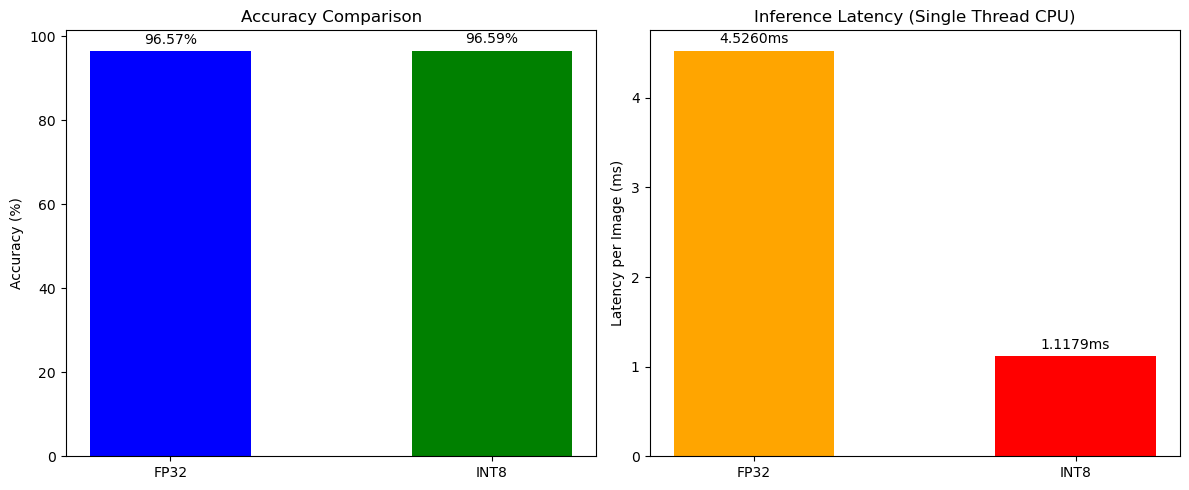

In [13]:
# 打印结果
print("\n================ 实验指标汇总 ================")
print(f"1. 精度指标: FP32 ({fp32_acc:.2f}%) vs INT8 ({int8_acc:.2f}%) | 精度损失: {fp32_acc - int8_acc:.2f}%")
print(f"2. 模型大小: FP32 ({fp32_size:.2f} MB) vs INT8 ({int8_size:.2f} MB) | 压缩比: {fp32_size / int8_size:.2f}x")
print(f"3. 推理速度: FP32 ({fp32_latency:.4f} ms/图) vs INT8 ({int8_latency:.4f} ms/图)")

# ==========================================
# 指标可视化
# ==========================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
bars = plt.bar(['FP32', 'INT8'], [fp32_acc, int8_acc], color=['blue', 'green'], width=0.5)
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy (%)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom')

plt.subplot(1, 2, 2)
bars = plt.bar(['FP32', 'INT8'], [fp32_latency, int8_latency], color=['orange', 'red'], width=0.5)
plt.title('Inference Latency (Single Thread CPU)')
plt.ylabel('Latency per Image (ms)')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.05, f'{yval:.4f}ms', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('resnet_quantization_comparison.png', dpi=300)

由实验结果可见，将参数从32位浮点压缩为8位定点后，模型体积缩小了约 4 倍，极大缓解了边缘设备的内存限制。
利用 CPU 的 INT8 向量化指令集（如 AVX2/VNNI），结合算子融合技术，模型的前向推理速度获得了显著提升，也缩短至接近1/4的时间。
同时INT8 模型的分类准确率几乎没有明显衰减，验证了INT8静态量化技术的可行性。